In [1]:
!gdown 14lX_JgofYZLbIkjPf7rXmBOpVIfMudDo -O kaggle.json
!mkdir -p /root/.kaggle
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download thedevastator/dailydialog-multi-turn-dialog-with-intention-and
!unzip dailydialog-multi-turn-dialog-with-intention-and.zip -d .

Downloading...
From: https://drive.google.com/uc?id=14lX_JgofYZLbIkjPf7rXmBOpVIfMudDo
To: /content/kaggle.json
100% 69.0/69.0 [00:00<00:00, 223kB/s]
Dataset URL: https://www.kaggle.com/datasets/thedevastator/dailydialog-multi-turn-dialog-with-intention-and
License(s): CC0-1.0
Archive:  dailydialog-multi-turn-dialog-with-intention-and.zip
  inflating: ./test.csv              
  inflating: ./train.csv             
  inflating: ./validation.csv        


In [2]:
import pandas as pd

df_train = pd.read_csv("train.csv")
df_train.head()


,dialog,act,emotion
0,"['Say , Jim , how about going for a few beers ...",[3 4 2 2 2 3 4 1 3 4],[0 0 0 0 0 0 4 4 4 4]
1,"['Can you do push-ups ? '\n "" Of course I can ...",[2 1 2 2 1 1],[0 0 6 0 0 0]
2,"['Can you study with the radio on ? '\n ' No ,...",[2 1 2 1 1],[0 0 0 0 0]
3,['Are you all right ? '\n ' I will be all righ...,[2 1 1 1],[0 0 0 0]
4,"['Hey John , nice skates . Are they new ? '\n ...",[2 1 2 1 1 2 1 3 4],[0 0 0 0 0 6 0 6 0]


In [3]:
df_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11118 entries, 0 to 11117
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   dialog   11118 non-null  object
 1   act      11118 non-null  object
 2   emotion  11118 non-null  object
dtypes: object(3)
memory usage: 260.7+ KB


In [4]:
print(df_train["dialog"].iloc[0])


['Say , Jim , how about going for a few beers after dinner ? '
 ' You know that is tempting but is really not good for our fitness . '
 ' What do you mean ? It will help us to relax . '
 " Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ? "
 " I guess you are right.But what shall we do ? I don't feel like sitting at home . "
 ' I suggest a walk over to the gym where we can play singsong and meet some of our friends . '
 " That's a good idea . I hear Mary and Sally often go there to play pingpong.Perhaps we can make a foursome with them . "
 ' Sounds great to me ! If they are willing , we could ask them to go dancing with us.That is excellent exercise and fun , too . '
 " Good.Let ' s go now . " ' All right . ']


In [5]:
import ast
import re

# Fix missing commas and convert string to list
def fix_and_eval_list(s):
    if isinstance(s, list): return s
    s_fixed = re.sub(r"(\d)\s+(?=\d)", r"\1, ", s)
    return ast.literal_eval(s_fixed)

# Extract utterances enclosed in quotes
def parse_dialog(s):
    utterances = re.findall(r"'(.*?)'|\"(.*?)\"", s)
    return [u[0] if u[0] else u[1] for u in utterances]

df_train["dialog"] = df_train["dialog"].apply(parse_dialog)
df_train["act"] = df_train["act"].apply(fix_and_eval_list)
df_train["emotion"] = df_train["emotion"].apply(fix_and_eval_list)

df_train.iloc[0]


,0
dialog,"[Say , Jim , how about going for a few beers a..."
act,"[3, 4, 2, 2, 2, 3, 4, 1, 3, 4]"
emotion,"[0, 0, 0, 0, 0, 0, 4, 4, 4, 4]"


In [6]:
len(df_train["dialog"][0]), len(df_train["act"][0]), len(df_train["emotion"][0])


(10, 10, 10)

Statistics on dialog turns:
count    11118.000000
mean         7.844486
std          4.013539
min          2.000000
25%          4.000000
50%          7.000000
75%         10.000000
max         35.000000
Name: num_turns, dtype: float64


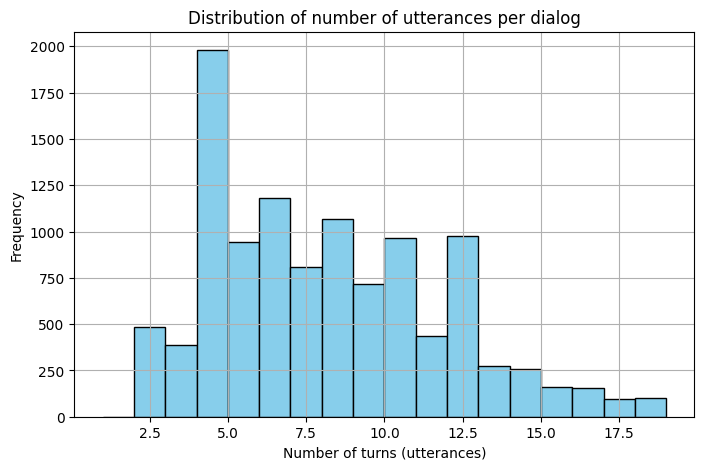

In [7]:
import matplotlib.pyplot as plt

# Compute number of utterances per dialog
df_train["num_turns"] = df_train["dialog"].apply(len)

print("Statistics on dialog turns:")
print(df_train["num_turns"].describe())

plt.figure(figsize=(8, 5))
plt.hist(df_train["num_turns"], bins=range(1, 20), color='skyblue', edgecolor='black')
plt.title("Distribution of number of utterances per dialog")
plt.xlabel("Number of turns (utterances)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


In [8]:
from collections import Counter

# Flatten all emotion lists into a single list
all_emotions = [emo for dialog_emotions in df_train["emotion"] for emo in dialog_emotions]

# Count emotion class frequencies
emotion_counts = Counter(all_emotions)

# Map class IDs to emotion labels
emotion_labels = {
    0: "no emotion",
    1: "anger",
    2: "disgust",
    3: "fear",
    4: "happiness",
    5: "sadness",
    6: "surprise"
}

# Print sorted emotion counts
for k, v in sorted(emotion_counts.items()):
    print(f"{emotion_labels[k]} ({k}): {v}")


no emotion (0): 72143
anger (1): 827
disgust (2): 303
fear (3): 146
happiness (4): 11182
sadness (5): 969
surprise (6): 1600


In [9]:
total_emotions = sum(emotion_counts.values())

# Print percentage for each emotion
for k, v in sorted(emotion_counts.items()):
    percentage = (v / total_emotions) * 100
    print(f"{emotion_labels[k]} ({k}): {v} → {percentage:.2f}%")


no emotion (0): 72143 → 82.76%
anger (1): 827 → 0.95%
disgust (2): 303 → 0.35%
fear (3): 146 → 0.17%
happiness (4): 11182 → 12.83%
sadness (5): 969 → 1.11%
surprise (6): 1600 → 1.84%


In [10]:
df_train["is_consistent"] = df_train.apply(
    lambda row: len(row["dialog"]) == len(row["act"]) == len(row["emotion"]), axis=1
)

print("Inconsistent dialogs (to exclude):", (~df_train["is_consistent"]).sum())


Inconsistent dialogs (to exclude): 32


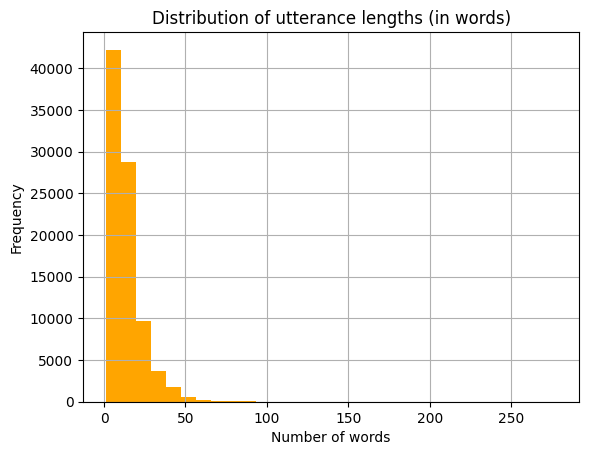

In [11]:
utterance_lengths = [len(u.split()) for dialog in df_train["dialog"] for u in dialog]

plt.hist(utterance_lengths, bins=30, color='orange')
plt.title("Distribution of utterance lengths (in words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


In [12]:
df_train = df_train[df_train["is_consistent"]].reset_index(drop=True)
print("Remaining dialogs:", len(df_train))


Remaining dialogs: 11086


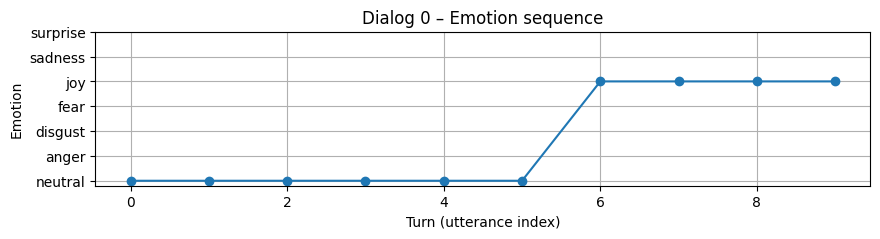

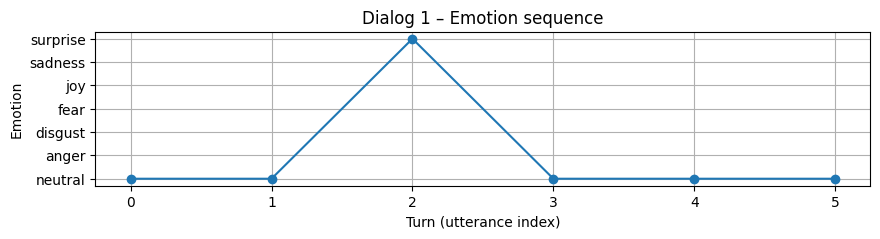

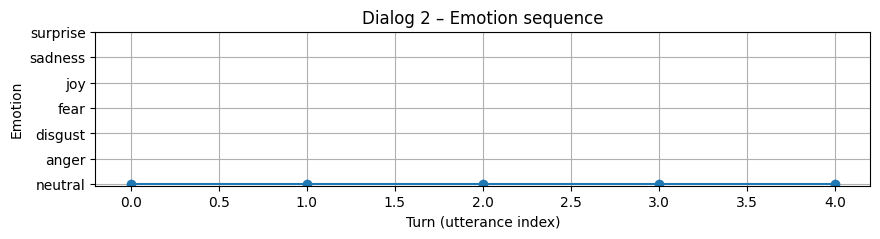

In [13]:
import matplotlib.pyplot as plt

# Map numeric labels to emotion names
emotion_labels = {
    0: "neutral", 1: "anger", 2: "disgust", 3: "fear",
    4: "joy", 5: "sadness", 6: "surprise"
}

# Visualize emotion sequences for the first few dialogs
for i in range(3):
    plt.figure(figsize=(10, 2))
    plt.plot(df_train["emotion"].iloc[i], marker='o')
    plt.title(f"Dialog {i} – Emotion sequence")
    plt.yticks(ticks=range(7), labels=[emotion_labels[k] for k in range(7)])
    plt.xlabel("Turn (utterance index)")
    plt.ylabel("Emotion")
    plt.grid(True)
    plt.show()


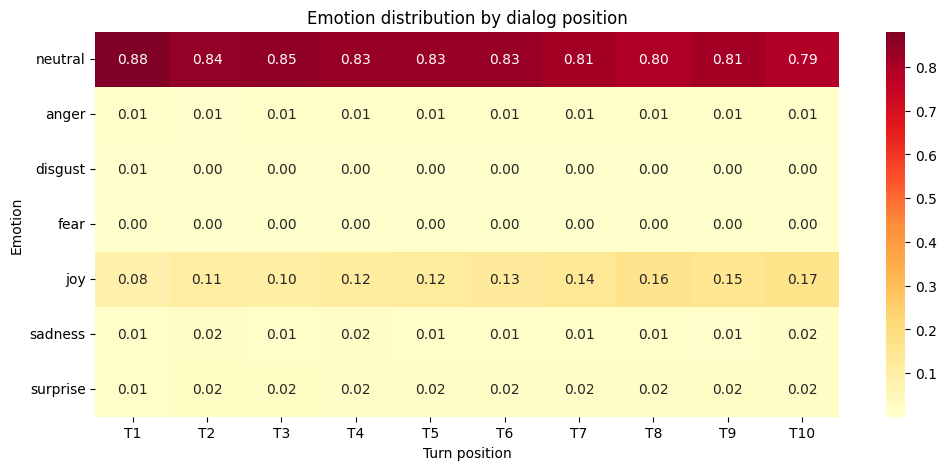

In [14]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Parameters
MAX_LEN = 10  # only analyze the first 10 turns
NUM_EMOTIONS = 7

# Matrix: rows = emotions, columns = dialog positions
emotion_position_matrix = np.zeros((NUM_EMOTIONS, MAX_LEN))

# Fill the matrix
for emotions in df_train["emotion"]:
    for i, emo in enumerate(emotions[:MAX_LEN]):
        emotion_position_matrix[emo, i] += 1

# Normalize each column to get emotion distribution per position
emotion_position_probs = emotion_position_matrix / emotion_position_matrix.sum(axis=0, keepdims=True)

# Heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(
    emotion_position_probs, annot=True, fmt=".2f", cmap="YlOrRd",
    xticklabels=[f"T{i}" for i in range(1, MAX_LEN + 1)],
    yticklabels=[emotion_labels[i] for i in range(NUM_EMOTIONS)]
)
plt.title("Emotion distribution by dialog position")
plt.xlabel("Turn position")
plt.ylabel("Emotion")
plt.show()


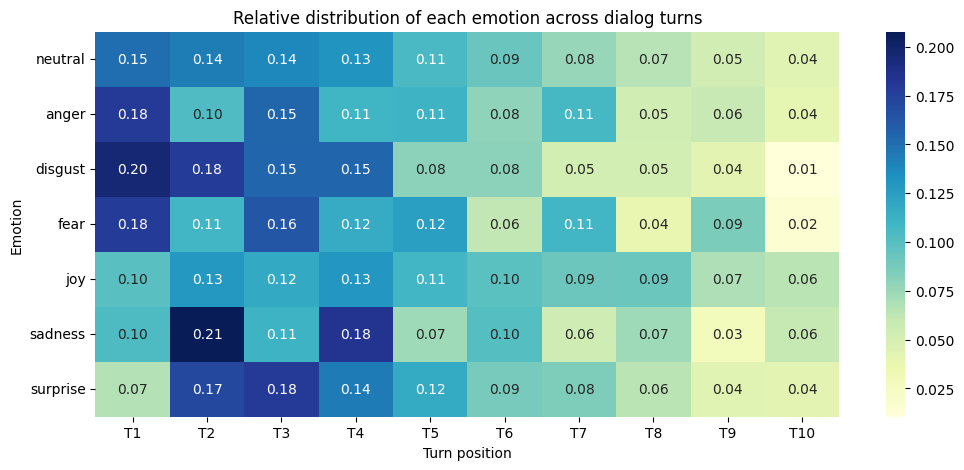

In [15]:
# Row-normalized: each row sums to 1 (distribution of turn positions per emotion)
emotion_position_probs_rownorm = emotion_position_matrix / emotion_position_matrix.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 5))
sns.heatmap(
    emotion_position_probs_rownorm, annot=True, fmt=".2f", cmap="YlGnBu",
    xticklabels=[f"T{i}" for i in range(1, MAX_LEN + 1)],
    yticklabels=[emotion_labels[i] for i in range(NUM_EMOTIONS)]
)
plt.title("Relative distribution of each emotion across dialog turns")
plt.xlabel("Turn position")
plt.ylabel("Emotion")
plt.show()


<ipython-input-16-106c1ed541b8>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


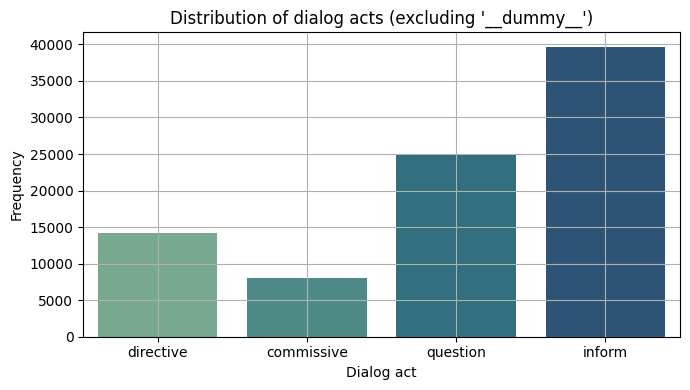

Percentage distribution:
inform (1): 39665 → 45.70%
question (2): 24857 → 28.64%
directive (3): 14206 → 16.37%
commissive (4): 8063 → 9.29%


In [16]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

# Official mapping from Hugging Face (0 is a placeholder and excluded)
act_labels = {
    1: "inform",
    2: "question",
    3: "directive",
    4: "commissive"
}

# Flatten all acts into a single list, excluding 0
all_acts = [a for dialog_acts in df_train["act"] for a in dialog_acts if a != 0]
act_counts = Counter(all_acts)

# Bar plot
plt.figure(figsize=(7, 4))
sns.barplot(
    x=[act_labels[k] for k in act_counts.keys()],
    y=list(act_counts.values()),
    palette="crest"
)
plt.title("Distribution of dialog acts (excluding '__dummy__')")
plt.ylabel("Frequency")
plt.xlabel("Dialog act")
plt.grid(True)
plt.tight_layout()
plt.show()

# Print percentages
total_acts = sum(act_counts.values())
print("Percentage distribution:")
for k, v in sorted(act_counts.items()):
    pct = (v / total_acts) * 100
    print(f"{act_labels[k]} ({k}): {v} → {pct:.2f}%")


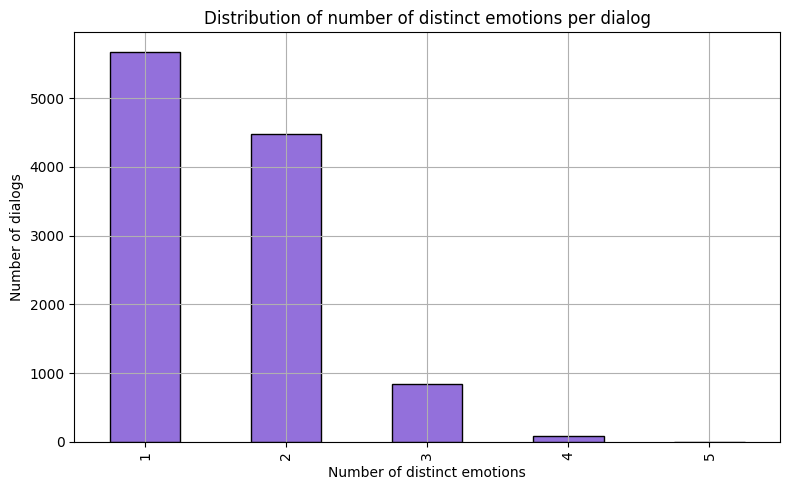

In [17]:
import matplotlib.pyplot as plt

# Count unique emotions per dialog
df_train["num_unique_emotions"] = df_train["emotion"].apply(lambda emo_list: len(set(emo_list)))

# Barplot of the distribution
plt.figure(figsize=(8, 5))
df_train["num_unique_emotions"].value_counts().sort_index().plot(kind="bar", color="mediumpurple", edgecolor="black")
plt.title("Distribution of number of distinct emotions per dialog")
plt.xlabel("Number of distinct emotions")
plt.ylabel("Number of dialogs")
plt.grid(True)
plt.tight_layout()
plt.show()
